In [53]:
# conda activate anndata

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Prep eigenges

In [54]:
top_mods_df1_Cur = pd.read_csv("data/EA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_EA_top_Qval_mods.csv")

cts = ["CGE Class"]
top_mods_df1_Cur = top_mods_df1_Cur[top_mods_df1_Cur['Cell_type'].isin(cts)]
top_mods_df1_Cur = top_mods_df1_Cur.rename(columns={"Module": "Mod"})

In [55]:
top_mods_df1_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")

cts = [
    "Micro/PVM", "All GABAergic", "Oligo", "Astro",
    "All Neuronal", "Endo",
    "L6 IT", "L2/3 IT"
]
top_mods_df1_FGSEA = top_mods_df1_FGSEA[top_mods_df1_FGSEA['Cell_type'].isin(cts)]
top_mods_df1_FGSEA.loc[top_mods_df1_FGSEA['Cell_type'] == "OPC", 'Cell_type'] = "Immature OPC"


In [56]:
top_mods_df2_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.93_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")
cts = ["OPC"]
top_mods_df2_FGSEA = top_mods_df2_FGSEA[top_mods_df2_FGSEA['Cell_type'].isin(cts)]

In [57]:
top_mods_df = pd.concat([top_mods_df1_Cur, top_mods_df1_FGSEA, top_mods_df2_FGSEA])

results = []
for idx, row in top_mods_df.iterrows():
    modEig = pd.read_csv(row['ME_path'], index_col=0)[row['Mod']]
    modEig.name = row['Cell_type']
    results.append(modEig)
    
eigengene_df = pd.concat(results, axis=1)

In [58]:
eigengene_df.head()

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Sample,,,,,,,,,,
GTEX.12126.0011.R10b.SM.5BC6T,0.146810,0.095824,-0.042099,-0.070946,-0.035843,-0.040700,-0.020068,-0.049773,0.045241,0.109267
GTEX.1F7RK.0011.R10b.SM.ARU7Y,0.068079,0.085535,0.021223,-0.019596,-0.093812,0.016217,0.066036,0.118367,0.049196,0.008826
GTEX.T5JC.0011.R10A.SM.32PM2,0.012689,0.001989,0.021835,-0.033105,-0.058511,-0.011044,0.035662,-0.018728,0.065645,0.002820
GTEX.WHSE.0011.R10A.SM.EYYVG,0.073536,0.084961,0.074458,-0.008586,0.003785,0.018067,-0.011331,0.004621,-0.023154,0.083886
GTEX.11ZUS.0011.R10b.SM.5BC79,0.027794,0.012384,0.147081,-0.040491,-0.050823,0.478469,-0.061926,-0.062080,-0.048608,0.013112


# Calc eigengene vs. gene expression correlation

In [59]:
bulk_expr = pd.read_csv("GTEx_frontal_cortex_counts_TMMF_SampleNetworks/All_10-58-02/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed.csv")
bulk_expr.columns.values[0] = "Gene"

In [60]:
# Make sure samples are in the same order

bulk_expr = bulk_expr.set_index("Gene")
common = bulk_expr.columns.intersection(eigengene_df.index)
bulk_expr = bulk_expr[common]
eigengene_df = eigengene_df.loc[common]

In [61]:
from scipy.stats import rankdata, norm

bulk_expr_rank_matrix = np.apply_along_axis(
    lambda x: rankdata(np.where(np.isnan(x), np.nan, x), method='average'),
    axis=1,
    arr=bulk_expr.values
) 

expr_rank_centered = bulk_expr_rank_matrix - np.nanmean(bulk_expr_rank_matrix, axis=1, keepdims=True)
expr_rank_norm = np.sqrt(np.nansum(expr_rank_centered ** 2, axis=1, keepdims=True)) 

corr_results = {}
for ct in eigengene_df.columns:
    ct_vals = eigengene_df[ct].values
    ct_ranks = rankdata(ct_vals, method='average')

    # --- observed correlation ---
    ct_centered = ct_ranks - ct_ranks.mean()
    ct_norm = np.sqrt((ct_centered ** 2).sum())
    observed = (expr_rank_centered @ ct_centered) / (expr_rank_norm.squeeze() * ct_norm)
    corr_results[ct] = observed
    
expr_corr_df = pd.DataFrame(corr_results, index=bulk_expr.index)

In [62]:
# # Correlate each cell type with gene expression

# expr_corr_results = {}
# for ct in eigengene_df.columns:
#     expr_corr_results[ct] = bulk_expr.T.corrwith(eigengene_df[ct])
    
# expr_corr_df = pd.DataFrame(expr_corr_results)

In [63]:
expr_corr_df.to_csv("data/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_ct_eigengenes_spearman_corr.csv")

# Cluster eigengenes by correlation

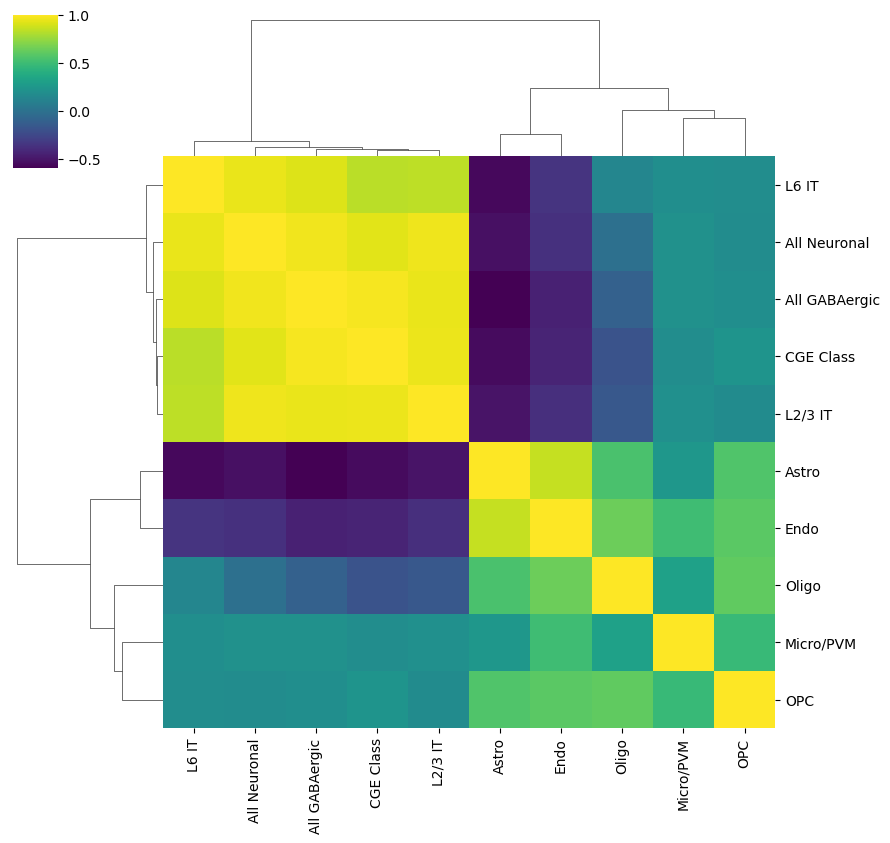

In [73]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, metric="euclidean", method="average", cmap='viridis', figsize=(9, 8.5))

# Manually inspect top genes

In [28]:
cts_to_keep = []

In [29]:
expr_corr_df.columns

Index(['CGE Class', 'All GABAergic', 'Micro/PVM', 'Oligo', 'Astro', 'Endo',
       'All Neuronal', 'L6 IT', 'L2/3 IT', 'OPC'],
      dtype='object')

In [30]:
expr_corr_df.sort_values("CGE Class", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
DLX1,0.974499,0.908217,0.146318,-0.179310,-0.220801,-0.140126,0.672266,0.370709,0.728493,0.324530
RGS8,0.966069,0.847644,0.080302,-0.206633,-0.260921,-0.153265,0.646509,0.323717,0.762391,0.303245
DLX6-AS1,0.963285,0.854448,0.105207,-0.210965,-0.268247,-0.138044,0.607830,0.320291,0.729696,0.306626
PTHLH,0.952777,0.877172,0.139877,-0.208142,-0.267209,-0.177231,0.676508,0.417244,0.701685,0.333418
TAC3,0.945943,0.809104,0.155801,-0.247725,-0.200669,-0.092957,0.593271,0.282358,0.707077,0.306302
PRLHR,0.941080,0.892452,0.114241,-0.134970,-0.264965,-0.170487,0.691153,0.400998,0.739643,0.281685
VIP,0.938921,0.784665,0.140870,-0.249225,-0.239175,-0.112950,0.507250,0.234844,0.658267,0.337229
SLC10A4,0.925057,0.847182,0.148130,-0.113356,-0.230037,-0.143942,0.700863,0.417100,0.737496,0.336161
DLX2,0.919178,0.847874,0.115209,-0.142822,-0.165789,-0.167809,0.614624,0.362952,0.626191,0.278800


In [31]:
expr_corr_df.sort_values("All GABAergic", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
GAD2,0.902025,0.984583,0.166504,-0.063134,-0.358473,-0.183177,0.771516,0.562478,0.665727,0.256170
GAD1,0.885301,0.983621,0.200212,-0.085319,-0.360060,-0.166585,0.792440,0.570829,0.674361,0.234004
ZNF385D,0.886629,0.976500,0.155587,0.019644,-0.306084,-0.119292,0.789888,0.647470,0.642940,0.352212
SLC32A1,0.880704,0.973568,0.148664,-0.096079,-0.431175,-0.232909,0.791024,0.569635,0.655171,0.184163
LGI2,0.857613,0.968384,0.159988,-0.036625,-0.409399,-0.157247,0.805868,0.636118,0.644887,0.243105
VWC2,0.874187,0.962418,0.167998,-0.027668,-0.313922,-0.125513,0.812084,0.645124,0.685622,0.319637
MYO5B,0.795839,0.956371,0.196349,-0.035732,-0.365810,-0.165678,0.801059,0.613353,0.628159,0.200717
BTBD11,0.911015,0.954840,0.141829,-0.117385,-0.222895,-0.145445,0.772140,0.502601,0.717780,0.274166
NXPH1,0.869680,0.951288,0.202460,0.014760,-0.220165,-0.081527,0.743542,0.587008,0.614726,0.463666


In [32]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
DLG3,0.699365,0.833242,0.072020,0.006195,-0.372837,-0.179881,0.983689,0.718734,0.769468,0.109977
ADD2,0.649434,0.805279,0.074784,0.037678,-0.342298,-0.151201,0.976793,0.751664,0.734985,0.116976
FAM234B,0.677630,0.814733,0.100570,-0.008285,-0.354799,-0.174646,0.976505,0.707098,0.771483,0.097384
RAB6B,0.679220,0.821935,0.132177,0.000152,-0.310608,-0.144467,0.976154,0.697432,0.766224,0.132152
TSPAN5,0.624049,0.764367,0.121095,0.065474,-0.278792,-0.103161,0.975968,0.693004,0.767677,0.118986
MAP2K4,0.641515,0.817162,0.157784,0.044989,-0.385861,-0.149170,0.975324,0.756203,0.727407,0.125135
INPP4A,0.687929,0.826512,0.161532,0.007245,-0.289401,-0.091784,0.975296,0.712479,0.777655,0.181464
NDRG3,0.634877,0.816253,0.180405,0.061992,-0.317234,-0.096769,0.975138,0.733526,0.717244,0.122117
PGAP4,0.642379,0.801509,0.106060,0.010301,-0.374153,-0.161050,0.975020,0.728501,0.753619,0.103930


In [33]:
expr_corr_df.loc['RBFOX3'].sort_values(ascending=False).head()

All Neuronal     0.844319
L2/3 IT          0.692540
All GABAergic    0.642150
L6 IT            0.625226
CGE Class        0.571538
Name: RBFOX3, dtype: float64

In [34]:
expr_corr_df.loc['SNAP25'].sort_values(ascending=False).head()

All Neuronal     0.953187
All GABAergic    0.804431
L6 IT            0.771396
L2/3 IT          0.669614
CGE Class        0.606846
Name: SNAP25, dtype: float64

In [35]:
expr_corr_df.loc['SYT1'].sort_values(ascending=False).head()

All Neuronal     0.956910
L6 IT            0.825672
All GABAergic    0.800125
L2/3 IT          0.640591
CGE Class        0.581359
Name: SYT1, dtype: float64

In [36]:
expr_corr_df.loc['ENO2'].sort_values(ascending=False).head()

All Neuronal     0.963662
All GABAergic    0.779617
L6 IT            0.748681
L2/3 IT          0.666009
CGE Class        0.589174
Name: ENO2, dtype: float64

In [37]:
expr_corr_df.sort_values("L6 IT", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
RXFP1,0.258132,0.534126,0.028213,0.305517,-0.398056,-0.124043,0.683428,0.964058,0.208336,0.119451
FOXP2,0.223729,0.504356,0.109371,0.330431,-0.321506,-0.036076,0.620749,0.944281,0.145907,0.168009
CHN2,0.246909,0.512885,0.104317,0.450179,-0.340743,-0.019500,0.658069,0.942328,0.199655,0.190322
CHRM2,0.531946,0.748369,0.062271,0.199319,-0.420873,-0.165373,0.796083,0.932593,0.404142,0.185574
CLMP,0.440648,0.684115,0.099032,0.294276,-0.394648,-0.045841,0.720077,0.930061,0.302966,0.175842
B3GALT2,0.431985,0.633652,0.056913,0.381778,-0.280780,-0.051975,0.740851,0.918344,0.351787,0.348156
SLC24A2,0.447727,0.711255,0.088001,0.298890,-0.362666,-0.073410,0.851883,0.915398,0.441088,0.147197
CLSTN2,0.381721,0.645565,0.084335,0.179907,-0.471769,-0.140362,0.826291,0.907208,0.400975,0.041388
CNIH3,0.503284,0.741890,0.022700,0.176713,-0.387737,-0.150575,0.871022,0.904466,0.465106,0.154838


In [38]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
HS6ST3,0.769468,0.757670,0.156760,-0.207392,-0.269387,-0.146389,0.848823,0.379935,0.943185,0.111111
ENSG00000234929,0.693611,0.601425,0.047652,-0.233535,-0.227406,-0.139145,0.697625,0.239131,0.931000,0.086294
CUX2,0.736598,0.623422,0.181001,-0.313418,-0.119271,-0.050799,0.650638,0.114424,0.929594,0.092846
GRIA4,0.816166,0.811771,0.126515,-0.123719,-0.235903,-0.115938,0.872656,0.447281,0.928216,0.211127
RASGRF2,0.789092,0.779575,0.170211,-0.182810,-0.285064,-0.136755,0.822643,0.367335,0.918704,0.141011
PCDH8,0.785033,0.717694,0.117987,-0.283113,-0.263240,-0.173419,0.763977,0.253463,0.912828,0.025942
LINC00507,0.766210,0.670443,0.159496,-0.229360,-0.229687,-0.120698,0.680231,0.230043,0.912140,0.093260
AKAP5,0.754630,0.760224,0.160761,-0.164329,-0.294475,-0.120342,0.863794,0.451814,0.911688,0.175048
GLRA3,0.683234,0.655177,0.076320,-0.187035,-0.305486,-0.167415,0.782445,0.354772,0.907701,0.132741


In [40]:
expr_corr_df.sort_values("OPC", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
BCHE,0.294333,0.223330,0.176727,0.321121,0.386788,0.339943,0.070848,0.144883,0.079962,0.948936
SEMA5A,0.233248,0.225432,0.283065,0.400618,0.403095,0.426716,0.119913,0.270583,0.039902,0.944496
LHFPL3,0.205351,0.123530,0.234549,0.268631,0.519655,0.429341,-0.008382,0.088318,0.019923,0.941128
PLPPR1,0.305214,0.256844,0.105130,0.488426,0.341691,0.320107,0.144557,0.267212,0.087674,0.922708
LUZP2,0.480855,0.459638,0.184634,0.204688,0.203117,0.202481,0.303906,0.333688,0.235077,0.917534
PCDH15,0.223201,0.141826,0.089272,0.245939,0.476767,0.363992,0.008807,0.103399,0.034525,0.874886
PDGFRA,0.202568,0.130671,0.164658,0.224314,0.512582,0.434594,0.014180,0.058143,0.061724,0.865736
CACNG4,0.404886,0.292854,0.051496,0.237886,0.380887,0.272584,0.164563,0.150566,0.192986,0.841992
BLM,0.316671,0.311648,0.237564,0.259724,0.388165,0.393536,0.161823,0.213374,0.136520,0.804739


In [41]:
expr_corr_df.sort_values("Micro/PVM", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
CSF1R,0.142781,0.191240,0.969890,0.093584,0.149471,0.394891,0.138509,0.094147,0.127251,0.160866
LAPTM5,0.048115,0.097379,0.962366,0.126432,0.181128,0.425057,0.075576,0.064514,0.049192,0.154463
NCKAP1L,0.132734,0.190350,0.961908,0.105589,0.133191,0.432680,0.168655,0.136841,0.144898,0.145180
SYK,0.052927,0.070182,0.955785,0.124551,0.240384,0.487194,0.042886,0.005184,0.073787,0.223950
APBB1IP,0.142208,0.206308,0.953509,0.105771,0.111990,0.415326,0.140266,0.119544,0.116533,0.170347
C3,0.088523,0.163212,0.950871,0.084659,0.106615,0.374370,0.146720,0.121166,0.105370,0.107170
TYROBP,0.091658,0.140884,0.947763,0.112492,0.141385,0.403717,0.087026,0.090167,0.050373,0.191352
TREM2,0.106918,0.136748,0.946558,0.130580,0.137999,0.388007,0.090340,0.103683,0.068745,0.197859
LILRB4,0.190881,0.243135,0.941479,0.072411,0.067694,0.335914,0.175762,0.120239,0.162996,0.148792


In [42]:
expr_corr_df.sort_values("Endo", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
TGFBR2,-0.113298,-0.131424,0.476946,0.314631,0.469525,0.954144,-0.109359,-0.041860,-0.076083,0.390593
PRKCH,-0.146816,-0.144824,0.404128,0.368844,0.479149,0.952558,-0.071655,0.008720,-0.098237,0.331358
MECOM,-0.219500,-0.223551,0.407824,0.312080,0.514454,0.936833,-0.139808,-0.076479,-0.123114,0.280659
FLI1,-0.097312,-0.095603,0.519577,0.283488,0.434141,0.934370,-0.065943,-0.021208,-0.051181,0.320507
CYYR1,-0.210200,-0.228966,0.333767,0.296185,0.564293,0.931285,-0.176827,-0.094775,-0.165225,0.361055
MYCT1,-0.029801,-0.074319,0.394729,0.325039,0.435186,0.931112,-0.056575,0.001469,-0.035146,0.429465
FOXC1,-0.182679,-0.216544,0.332045,0.314025,0.499194,0.914708,-0.183251,-0.108486,-0.147656,0.299011
ABCB1,-0.077271,-0.094804,0.325954,0.352857,0.456275,0.906972,-0.028508,0.019559,-0.030247,0.363566
ADGRL4,-0.328408,-0.337108,0.351561,0.305190,0.564377,0.886965,-0.220074,-0.128130,-0.218927,0.228691


In [43]:
expr_corr_df.loc['CLDN5'].sort_values(ascending=False).head()

Endo         0.630917
Astro        0.536692
Oligo        0.284613
Micro/PVM    0.171087
OPC          0.115678
Name: CLDN5, dtype: float64

In [44]:
expr_corr_df.loc['NOSTRIN'].sort_values(ascending=False).head()

Endo         0.730898
Astro        0.602573
Oligo        0.302955
OPC          0.176986
Micro/PVM    0.171262
Name: NOSTRIN, dtype: float64

In [45]:
expr_corr_df.loc['PECAM1'].sort_values(ascending=False).head()

Endo         0.803215
Astro        0.510976
Micro/PVM    0.358692
Oligo        0.330610
OPC          0.113236
Name: PECAM1, dtype: float64

In [46]:
expr_corr_df.loc['FLT1'].sort_values(ascending=False).head()

Endo         0.783344
Astro        0.448708
Micro/PVM    0.332521
Oligo        0.288688
OPC          0.269246
Name: FLT1, dtype: float64

In [47]:
expr_corr_df.sort_values("Astro", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
MSI2,-0.217819,-0.330502,0.186827,0.169435,0.964862,0.519037,-0.297943,-0.349470,-0.157217,0.367490
NPAS3,-0.237136,-0.354207,0.104847,0.240212,0.963293,0.459649,-0.342091,-0.346017,-0.216775,0.368501
PON2,-0.300873,-0.407482,0.167961,0.227593,0.962648,0.496232,-0.415572,-0.392963,-0.300012,0.351187
DHTKD1,-0.152177,-0.241313,0.182204,0.261403,0.958816,0.536905,-0.217967,-0.234316,-0.133745,0.456370
PPARA,-0.228391,-0.355548,0.155062,0.178887,0.958306,0.514555,-0.366389,-0.368061,-0.217196,0.416185
STOX1,-0.169728,-0.290323,0.146792,0.141679,0.957303,0.468052,-0.303971,-0.366887,-0.160410,0.403602
GRAMD1C,-0.346884,-0.452647,0.111016,0.163992,0.956430,0.451685,-0.405580,-0.412791,-0.262333,0.250640
S1PR1,-0.277282,-0.401650,0.158900,0.185694,0.956292,0.519232,-0.384832,-0.396937,-0.249929,0.333904
ALDH9A1,-0.159077,-0.251397,0.203330,0.196703,0.956085,0.525154,-0.223320,-0.294261,-0.126443,0.427295


In [48]:
expr_corr_df.loc['SLC1A3'].sort_values(ascending=False).head()

Astro        0.933682
Endo         0.430068
OPC          0.214990
Micro/PVM    0.129170
Oligo        0.099089
Name: SLC1A3, dtype: float64

In [49]:
expr_corr_df.sort_values("Oligo", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
MOG,-0.214684,-0.035120,0.091504,0.966867,0.185178,0.270611,0.039785,0.364362,-0.245499,0.282568
MAG,-0.212696,-0.035131,0.063191,0.959497,0.112099,0.228882,0.051928,0.351160,-0.245232,0.222645
ENPP2,-0.104332,0.069881,0.147491,0.956041,0.109317,0.307026,0.133763,0.436323,-0.143722,0.378327
MYRF,-0.250683,-0.070058,0.078687,0.955969,0.171382,0.260644,0.037742,0.340432,-0.247677,0.193244
TMEM88B,-0.222870,-0.068949,0.055857,0.953863,0.197114,0.256106,0.000857,0.341614,-0.278326,0.323681
FA2H,-0.130272,0.029015,0.038615,0.947118,0.124533,0.232180,0.109588,0.428913,-0.198401,0.333796
TF,-0.128910,0.048148,0.098792,0.942837,0.070032,0.226816,0.134057,0.422078,-0.161172,0.286834
EVI2A,-0.187169,-0.031628,0.199140,0.942417,0.207164,0.333404,0.015206,0.347520,-0.224344,0.398227
CLDN11,-0.238525,-0.046776,0.133847,0.941536,0.098656,0.280342,0.049807,0.352962,-0.231034,0.215098


# Save data

In [52]:
expr_corr_df = expr_corr_df.rename(columns={'L6 IT': 'Deep layer glutamatergic', 'L2/3 IT': 'Upper layer glutamatergic'})
expr_corr_df.to_csv("data/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_ct_eigengenes_gene_expr_spearman_corr.csv")

In [ ]:
eigengene_df = eigengene_df.rename(columns={'L6 IT': 'Deep layer glutamatergic', 'L2/3 IT': 'Upper layer glutamatergic'})
eigengene_df.to_csv("data/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_ct_eigengenes.csv")